## Import Libraries

In [1]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tifffile import imread
from scipy import ndimage as ndi
from scipy.spatial.distance import directed_hausdorff

from skimage import exposure, filters, morphology, measure, feature
from skimage.color import rgb2hed
from skimage.segmentation import watershed, mark_boundaries
from skimage.draw import polygon
from skimage.metrics import adapted_rand_error

## Segmentation Function

In [3]:
def segment_nuclei_he_watershed(image_path, min_size=80, sigma=1.0):
    img = imread(image_path)

    if img.dtype != np.uint8:
        img = exposure.rescale_intensity(img, out_range=np.uint8).astype(np.uint8)

    hed = rgb2hed(img)
    hematoxylin = hed[:, :, 0]
    hematoxylin_inv = exposure.rescale_intensity(-hematoxylin, out_range=(0, 1))

    # Important correction: smooth the inverted image
    smooth = filters.gaussian(hematoxylin, sigma=sigma)
    thresh = filters.threshold_otsu(smooth)
    binary = smooth > thresh

    # An Opening, then closing morphological operation is utilized
    binary = morphology.remove_small_objects(binary, min_size=min_size)
    binary = morphology.remove_small_holes(binary, area_threshold=min_size)
    binary = morphology.binary_opening(binary, morphology.disk(1))
    binary = morphology.binary_closing(binary, morphology.disk(1))

    labeled_temp = measure.label(binary)
    props = measure.regionprops(labeled_temp)
    areas = np.array([prop.area for prop in props])

    # This roughly makes the minimum separation between nuclei to be equal to 1 median radius
    if len(areas) > 0:
        radius = np.sqrt(np.median(areas) / np.pi)
        min_distance = max(1, int(radius + 1.5))
    else:
        radius = 0
        min_distance = 1

    #distance transform
    distance = ndi.distance_transform_edt(binary)

    coords = feature.peak_local_max(
        distance,
        min_distance=min_distance,
        labels=binary
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(coords, start=1):
        markers[r, c] = i

    #watershed transform
    labels = watershed(-distance, markers, mask=binary)
    overlay = mark_boundaries(img, labels, color=(0, 1, 0), mode="thick")

    return img, hematoxylin, binary, labels, overlay

## Read Annotations and Convert to Mask

In [5]:
def xml_to_mask(image_path, xml_path):
    """
    Convert XML polygon annotations into a binary mask
    matching the image dimensions.
    """
    img = imread(image_path)
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for region in root.findall(".//Region"):
        vertices = region.findall(".//Vertices/Vertex")

        xs = []
        ys = []

        for v in vertices:
            xs.append(float(v.attrib["X"]))
            ys.append(float(v.attrib["Y"]))

        if len(xs) >= 3:
            rr, cc = polygon(ys, xs, shape=mask.shape)
            mask[rr, cc] = 1

    return mask

In [7]:
def compute_binary_metrics(gt_mask, pred_mask):
    """
    Compute pixel-level overlap metrics between
    ground truth mask and predicted mask.
    """
    gt = gt_mask.astype(bool)
    pred = pred_mask.astype(bool)

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()
    tn = np.logical_and(~gt, ~pred).sum()

    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "specificity": specificity
    }
    
def mask_boundaries(mask):
    """
    Extract boundary pixels from a binary mask.
    """
    eroded = morphology.binary_erosion(mask)
    boundary = mask.astype(bool) ^ eroded
    return boundary


def hausdorff_distance_masks(gt_mask, pred_mask):
    """
    Symmetric Hausdorff distance between boundary points.
    """
    gt_b = np.argwhere(mask_boundaries(gt_mask))
    pred_b = np.argwhere(mask_boundaries(pred_mask))

    if len(gt_b) == 0 or len(pred_b) == 0:
        return np.nan

    hd1 = directed_hausdorff(gt_b, pred_b)[0]
    hd2 = directed_hausdorff(pred_b, gt_b)[0]
    return max(hd1, hd2)


def mean_surface_distance(gt_mask, pred_mask):
    """
    Average distance between boundaries using distance transforms.
    """
    gt_b = mask_boundaries(gt_mask)
    pred_b = mask_boundaries(pred_mask)

    if gt_b.sum() == 0 or pred_b.sum() == 0:
        return np.nan

    dt_gt = ndi.distance_transform_edt(~gt_b)
    dt_pred = ndi.distance_transform_edt(~pred_b)

    dist_pred_to_gt = dt_gt[pred_b]
    dist_gt_to_pred = dt_pred[gt_b]

    return (dist_pred_to_gt.mean() + dist_gt_to_pred.mean()) / 2.0

def compute_instance_metrics(gt_mask, pred_labels):
    """
    Compute instance-related summary metrics.
    """
    gt_labels = measure.label(gt_mask)
    gt_count = gt_labels.max()
    pred_count = pred_labels.max()

    are, precision, recall = adapted_rand_error(gt_labels, pred_labels)

    return {
        "gt_nuclei_count": gt_count,
        "pred_nuclei_count": pred_count,
        "count_difference": pred_count - gt_count,
        "adapted_rand_error": are,
        "adapted_rand_precision": precision,
        "adapted_rand_recall": recall
    }

In [9]:
def evaluate_segmentation_against_xml(image_path, xml_path, min_size=80, sigma=1.0):
    """
    Segment one image, convert XML to ground-truth mask,
    and compute comparison metrics.
    """
    img, hematoxylin, pred_binary, pred_labels, overlay = segment_nuclei_he_watershed(
        image_path, min_size=min_size, sigma=sigma
    )

    gt_mask = xml_to_mask(image_path, xml_path)

    binary_metrics = compute_binary_metrics(gt_mask, pred_binary)
    instance_metrics = compute_instance_metrics(gt_mask, pred_labels)

    hd = hausdorff_distance_masks(gt_mask, pred_binary)
    msd = mean_surface_distance(gt_mask, pred_binary)

    metrics = {
        "image_name": os.path.basename(image_path),
        **binary_metrics,
        **instance_metrics,
        "hausdorff_distance": hd,
        "mean_surface_distance": msd
    }

    return {
        "img": img,
        "gt_mask": gt_mask,
        "pred_binary": pred_binary,
        "pred_labels": pred_labels,
        "overlay": overlay,
        "metrics": metrics
    }

# Single Image Usage: plotting function and usage

## Plotting Function

In [11]:
def plot_segmentation_vs_ground_truth(img, pred_labels, gt_mask, title="Segmentation vs Ground Truth"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(gt_mask, cmap="Greys")
    axes[1].set_title("Ground truth XML mask")
    axes[1].axis("off")

    axes[2].imshow(img)
    axes[2].imshow(mark_boundaries(img, pred_labels, color=(0, 1, 0), mode="thick"))
    axes[2].imshow(np.ma.masked_where(gt_mask == 0, gt_mask), cmap="gray", alpha=0.6)
    axes[2].set_title("Segmentation and Mask Overlay")
    axes[2].axis("off")

    plt.tight_layout()

## Usage Block

image_name                TCGA-B0-5711-01Z-00-DX1.tif
dice                                         0.798537
iou                                          0.664637
precision                                    0.735168
recall                                       0.873861
specificity                                  0.961619
gt_nuclei_count                                   300
pred_nuclei_count                                 297
count_difference                                   -3
adapted_rand_error                           0.710733
adapted_rand_precision                       0.808615
adapted_rand_recall                          0.176138
hausdorff_distance                          53.160135
mean_surface_distance                        2.725576
dtype: object


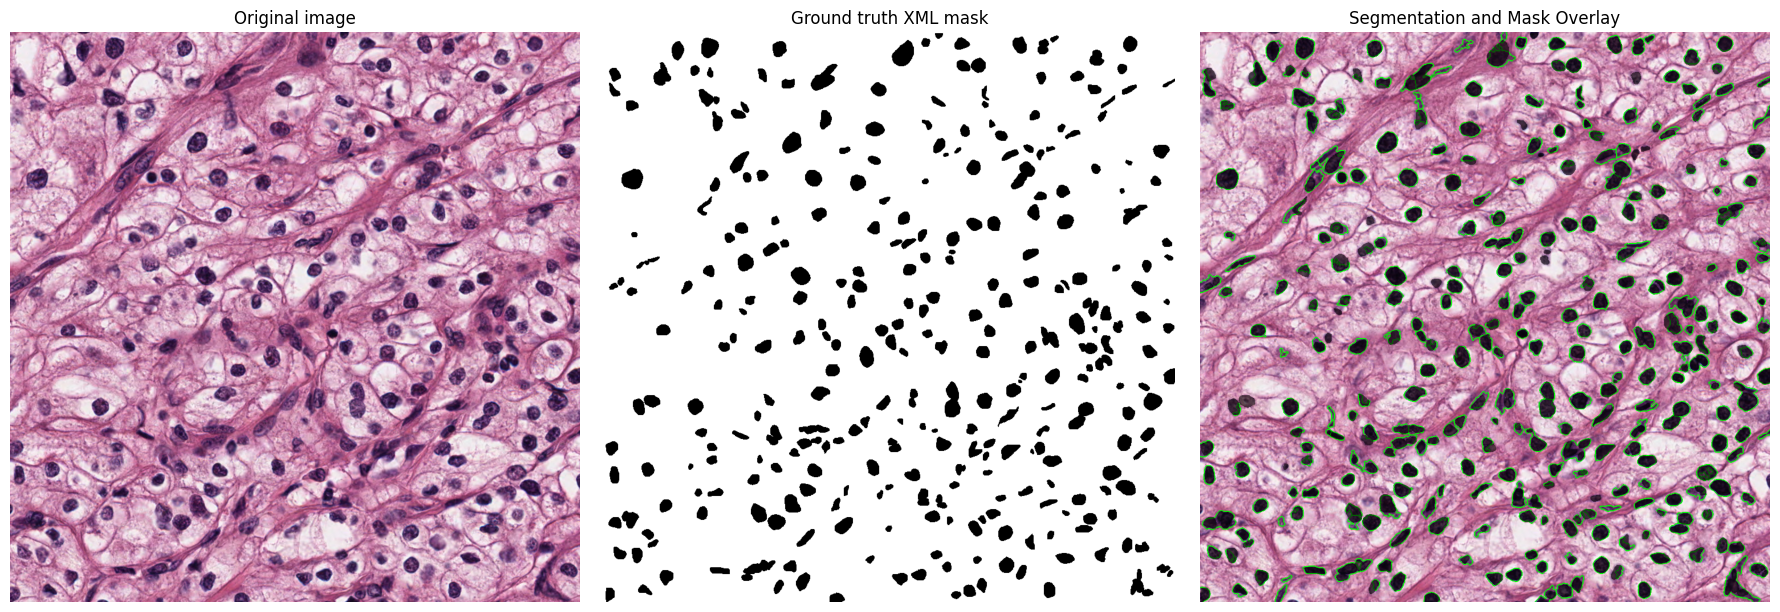

In [43]:
image_path = "./Dataset/Train/Tissue Images/TCGA-B0-5711-01Z-00-DX1.tif"
xml_path = "./Dataset/Train/Annotations/TCGA-B0-5711-01Z-00-DX1.xml"

result = evaluate_segmentation_against_xml(image_path, xml_path, min_size=80, sigma=1)

print(pd.Series(result["metrics"]))

plot_segmentation_vs_ground_truth(
    result["img"],
    result["pred_labels"],
    result["gt_mask"],
    title=f'{result["metrics"]["image_name"]}'
)

plt.savefig("first_segmentation_overlay.jpg", dpi=300, bbox_inches="tight")
plt.show()

# Batch Image Usage: evaluation function and usage

## Evaluation function

In [13]:
def evaluate_dataset(image_folder, xml_folder, min_size=80, sigma=1.0,
                     image_ext=".tif", xml_ext=".xml"):
    """
    Evaluate all matching image/XML pairs in two folders.
    """
    results = []

    image_files = sorted([f for f in os.listdir(image_folder) if f.endswith(image_ext)])

    for image_file in image_files:
        base_name = os.path.splitext(image_file)[0]
        xml_file = base_name + xml_ext

        image_path = os.path.join(image_folder, image_file)
        xml_path = os.path.join(xml_folder, xml_file)

        if not os.path.exists(xml_path):
            print(f"Skipping {image_file}: matching XML not found")
            continue

        try:
            out = evaluate_segmentation_against_xml(
                image_path=image_path,
                xml_path=xml_path,
                min_size=min_size,
                sigma=sigma
            )
            results.append(out["metrics"])
            print(f"Processed: {image_file}")
        except Exception as e:
            print(f"Failed on {image_file}: {e}")

    return pd.DataFrame(results)

## Usage Function

In [27]:
xml_folder = "./Dataset/Annotations/"
image_folder = "./Dataset/images/"

df_results = evaluate_dataset(
    image_folder=image_folder,
    xml_folder=xml_folder,
    min_size=80,
    sigma=1.0
)

df_results.head()

df_results.to_csv("segmentation_train_evaluation_results.csv", index=False)

Processed: TCGA-18-5592-01Z-00-DX1.tif
Processed: TCGA-21-5784-01Z-00-DX1.tif
Processed: TCGA-21-5786-01Z-00-DX1.tif
Processed: TCGA-2Z-A9J9-01A-01-TS1.tif
Processed: TCGA-38-6178-01Z-00-DX1.tif
Processed: TCGA-44-2665-01B-06-BS6.tif
Processed: TCGA-49-4488-01Z-00-DX1.tif
Processed: TCGA-50-5931-01Z-00-DX1.tif
Processed: TCGA-69-7764-01A-01-TS1.tif
Processed: TCGA-A6-6782-01A-01-BS1.tif
Processed: TCGA-A7-A13E-01Z-00-DX1.tif
Processed: TCGA-A7-A13F-01Z-00-DX1.tif
Processed: TCGA-AC-A2FO-01A-01-TS1.tif
Processed: TCGA-AO-A0J2-01A-01-BSA.tif
Processed: TCGA-AR-A1AK-01Z-00-DX1.tif
Processed: TCGA-AR-A1AS-01Z-00-DX1.tif
Processed: TCGA-AY-A8YK-01A-01-TS1.tif
Processed: TCGA-B0-5698-01Z-00-DX1.tif
Processed: TCGA-B0-5710-01Z-00-DX1.tif
Processed: TCGA-B0-5711-01Z-00-DX1.tif
Processed: TCGA-BC-A217-01Z-00-DX1.tif
Processed: TCGA-CH-5767-01Z-00-DX1.tif
Processed: TCGA-CU-A0YN-01A-02-BSB.tif
Processed: TCGA-DK-A2I6-01A-01-TS1.tif
Processed: TCGA-E2-A14V-01Z-00-DX1.tif
Processed: TCGA-E2-A1B5-0

## Metrics by Tissue Type

In [31]:
# Load the TCGA tissue code table
tcga_codes = pd.read_csv("TCGA_codes.txt", sep="\t")

# Create dictionary: TSS Code -> Study Name
tissue_dict = dict(zip(tcga_codes["TSS Code"], tcga_codes["Study Name"]))


def get_tissue_type(filename):
    # Extract TSS code from filename
    # TCGA-B0-XXXX → B0
    tss_code = filename.split("-")[1]
    
    return tissue_dict.get(tss_code, "Unknown")

def group_tissue(cancer_name):
    if "Breast" in cancer_name:
        return "Breast"
    elif "Kidney" in cancer_name:
        return "Kidney"
    elif "Lung" in cancer_name:
        return "Lung"
    elif "Colon" in cancer_name or "Rectum" in cancer_name:
        return "Colon"
    elif "Liver" in cancer_name:
        return "Liver"
    elif "Head and Neck" in cancer_name:
        return "Head & Neck"
    elif "Prostate" in cancer_name:
        return "Prostate"
    elif "Bladder" in cancer_name:
        return "Bladder"
    elif "Skin" in cancer_name:
        return "Skin"
    elif "Pancreatic" in cancer_name:
        return "Pancreas"
    elif "Stomach" in cancer_name:
        return "Stomach"
    elif "Cervical" in cancer_name:
        return "Cervical"
    else:
        return "Other"


In [33]:
df_results["tissue_type"] = df_results["image_name"].apply(get_tissue_type)
df_results["tissue_group"] = df_results["tissue_type"].apply(group_tissue)
df_results.to_csv("segmentation_train_evaluation_results.csv", index=False)

In [35]:
print(df_results.shape)
print(df_results.columns)

(30, 16)
Index(['image_name', 'dice', 'iou', 'precision', 'recall', 'specificity',
       'gt_nuclei_count', 'pred_nuclei_count', 'count_difference',
       'adapted_rand_error', 'adapted_rand_precision', 'adapted_rand_recall',
       'hausdorff_distance', 'mean_surface_distance', 'tissue_type',
       'tissue_group'],
      dtype='object')


# Plotting Functions

## Segmentation Overlap Metrics

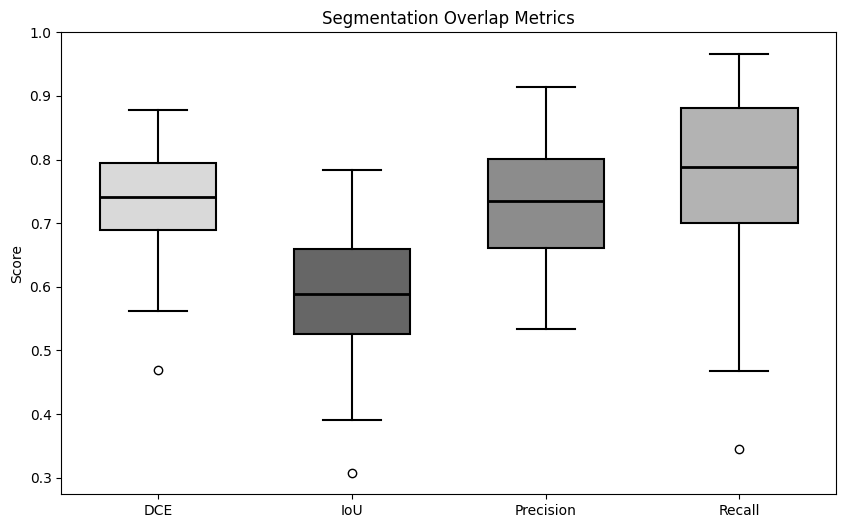

In [37]:
metrics = ["dice", "iou", "precision", "recall"]
labels_display = ["DCE", "IoU", "Precision", "Recall"]

data = [df_results[m].dropna() for m in metrics]

plt.figure(figsize=(10, 6))

box = plt.boxplot(
    data,
    patch_artist=True,   # allows box fill
    widths=0.6
)

# Shades of gray for each box
gray_colors = ["0.85", "0.4", "0.55", "0.7"]

# Style boxes
for patch, color in zip(box['boxes'], gray_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style whiskers, caps, medians
for whisker in box['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(1.5)

for cap in box['caps']:
    cap.set_color('black')
    cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Remove gridlines
plt.grid(False)

## Axis labels
# Use custom axis labels here
plt.xticks([1, 2, 3, 4], labels_display)
plt.yticks(np.arange(0.3, 1.1, 0.1))
plt.ylabel("Score")
plt.title("Segmentation Overlap Metrics")
plt.savefig("Segmentation_Overlap_Metrics.jpg", dpi=300, bbox_inches="tight")

plt.show()



## Overlap vs Boundary Error

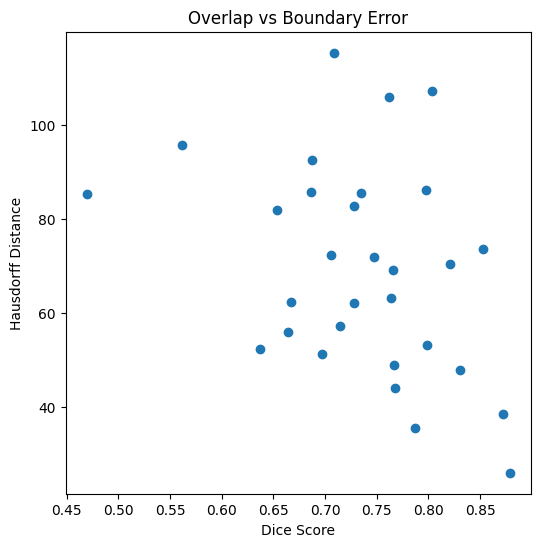

In [39]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df_results["dice"],
    df_results["hausdorff_distance"]
)

plt.xlabel("Dice Score")
plt.ylabel("Hausdorff Distance")
plt.title("Overlap vs Boundary Error")

plt.show()

## Predicted vs ground truth nuclei count

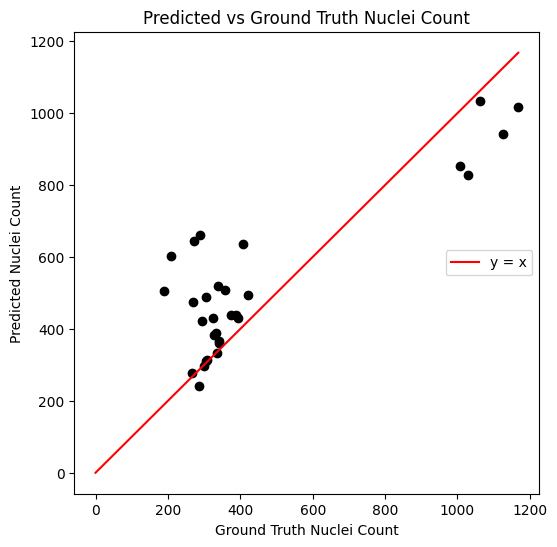

In [41]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df_results["gt_nuclei_count"],
    df_results["pred_nuclei_count"],
    color = 'black'
)

plt.xlabel("Ground Truth Nuclei Count")
plt.ylabel("Predicted Nuclei Count")
plt.title("Predicted vs Ground Truth Nuclei Count")

# Plot y = x line
max_val = max(df_results["gt_nuclei_count"].max(),
              df_results["pred_nuclei_count"].max())
plt.plot([0, max_val], [0, max_val], color = 'red', label='y = x')
plt.legend(loc= 'center right')


plt.savefig("Predicted vs ground truth nuclei count.jpg", dpi=300, bbox_inches="tight")

plt.show() 

## DCE by tissue type

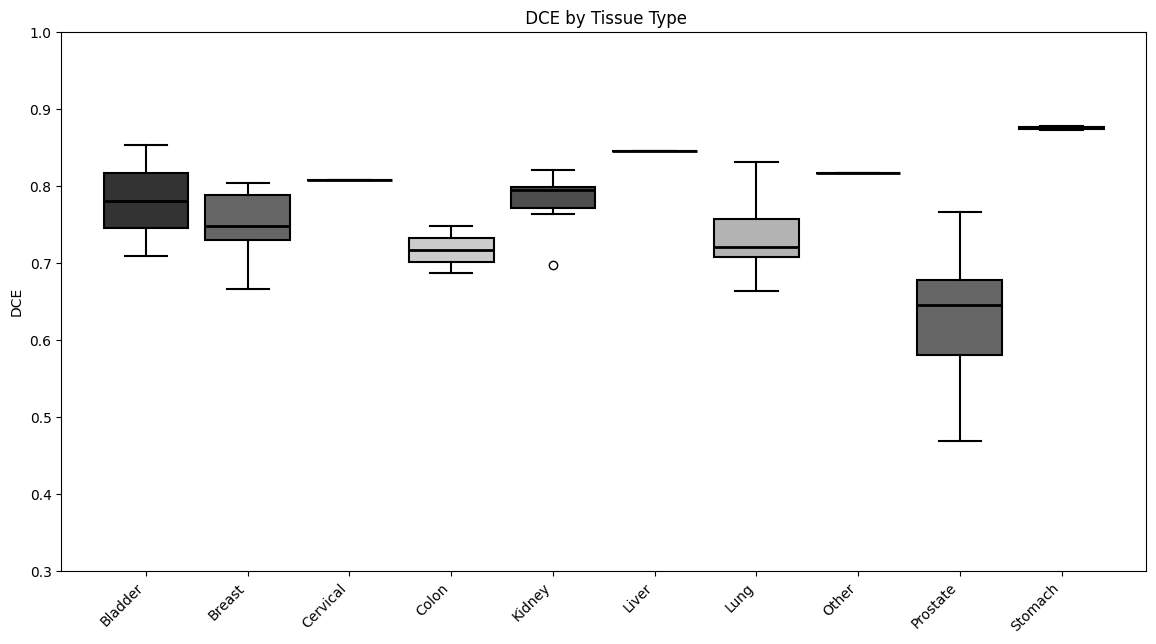

In [687]:
metrics = ["dice"]
labels_display = ["DCE"]
tissues = sorted(df_results["tissue_group"].dropna().unique())

fig, ax = plt.subplots(figsize=(14, 7))

positions = []
data = []
colors = ["0.2", "0.4", "0.6", "0.8", "0.3", "0.5", "0.7"]


pos = 0.5
for tissue in tissues:
    df_t = df_results[df_results["tissue_group"] == tissue]

    for m in metrics:
        data.append(df_t[m].dropna())
        positions.append(pos)
        pos += 0.1

    pos += 0.5   # space between tissue groups

box = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.5
)

# Style boxes
for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.5)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.5)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

# X-axis labels centered on each tissue box
tick_positions = positions
tick_labels = tissues

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.grid(False)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0.3, 1)
plt.ylabel("DCE")
plt.title(" DCE by Tissue Type")

plt.savefig("DCE_By_Tissue.jpg", dpi=300, bbox_inches="tight")
plt.show()

## Hausdorff dist by tissue type

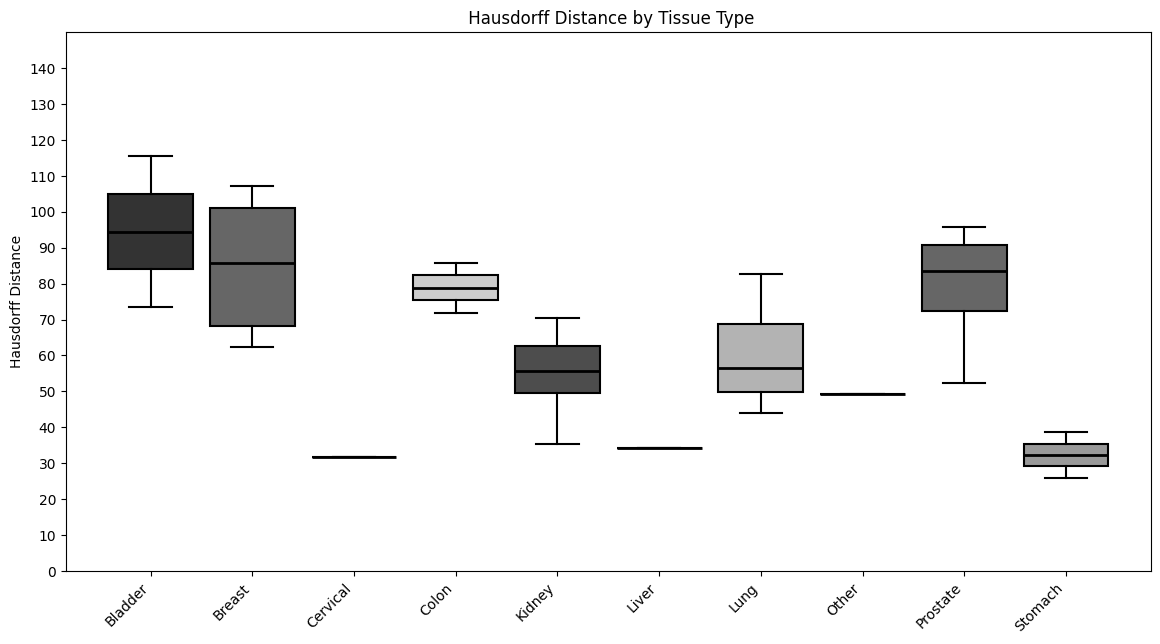

In [697]:
metrics = ["hausdorff_distance"]
labels_display = ["Hausdorff Distance"]
tissues = sorted(df_results["tissue_group"].dropna().unique())

fig, ax = plt.subplots(figsize=(14, 7))

positions = []
data = []
colors = ["0.2", "0.4", "0.6", "0.8", "0.3", "0.5", "0.7"]


pos = 0.5
for tissue in tissues:
    df_t = df_results[df_results["tissue_group"] == tissue]

    for m in metrics:
        data.append(df_t[m].dropna())
        positions.append(pos)
        pos += 0.1

    pos += 0.5   # space between tissue groups

box = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.5
)

# Style boxes
for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.5)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.5)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

# X-axis labels centered on each tissue box
tick_positions = positions
tick_labels = tissues

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.grid(False)
plt.yticks(np.arange(0, 150, 10))
plt.ylim(0, 150)
plt.ylabel("Hausdorff Distance")
plt.title(" Hausdorff Distance by Tissue Type")

plt.savefig("HD_By_Tissue.jpg", dpi=300, bbox_inches="tight")
plt.show()

## Error of Nuclei Count by Tissue Type

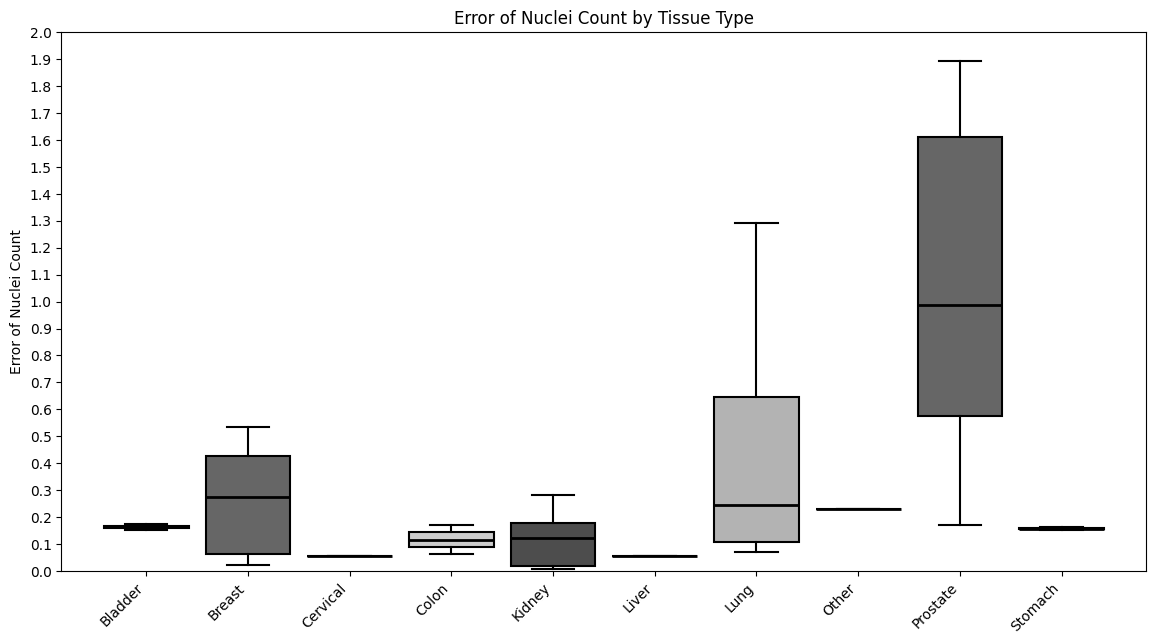

In [713]:
## Percent Nuclei Count by tissue type
df_results["count_error"] = (df_results["count_difference"].abs() / df_results["gt_nuclei_count"])
metrics = ["count_error"]
labels_display = ["Percent Nuclei Count"]
tissues = sorted(df_results["tissue_group"].dropna().unique())

fig, ax = plt.subplots(figsize=(14, 7))

positions = []
data = []
colors = ["0.2", "0.4", "0.6", "0.8", "0.3", "0.5", "0.7"]


pos = 0.5
for tissue in tissues:
    df_t = df_results[df_results["tissue_group"] == tissue]

    for m in metrics:
        data.append(df_t[m].dropna())
        positions.append(pos)
        pos += 0.1

    pos += 0.5   # space between tissue groups

box = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.5
)

# Style boxes
for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

for whisker in box["whiskers"]:
    whisker.set_color("black")
    whisker.set_linewidth(1.5)

for cap in box["caps"]:
    cap.set_color("black")
    cap.set_linewidth(1.5)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

# X-axis labels centered on each tissue box
tick_positions = positions
tick_labels = tissues

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.grid(False)
plt.yticks(np.arange(0, 2.1, 0.1))
plt.ylim(0, 2)
plt.ylabel("Error of Nuclei Count")
plt.title("Error of Nuclei Count by Tissue Type")

plt.savefig("Nuclei_By_Tissue.jpg", dpi=300, bbox_inches="tight")
plt.show()

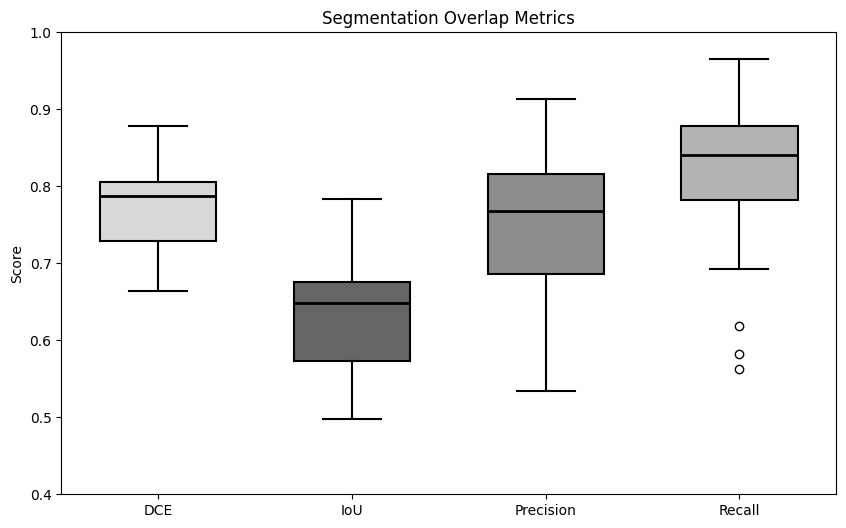

In [829]:
# Remove Prostate tissue
df_filtered = df_results[df_results["tissue_group"] != "Prostate"]

metrics = ["dice", "iou", "precision", "recall"]
labels_display = ["DCE", "IoU", "Precision", "Recall"]

data = [df_filtered[m].dropna() for m in metrics]

plt.figure(figsize=(10, 6))

box = plt.boxplot(
    data,
    patch_artist=True,   # allows box fill
    widths=0.6
)

# Shades of gray for each box
gray_colors = ["0.85", "0.4", "0.55", "0.7"]

# Style boxes
for patch, color in zip(box['boxes'], gray_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style whiskers, caps, medians
for whisker in box['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(1.5)

for cap in box['caps']:
    cap.set_color('black')
    cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Remove gridlines
plt.grid(False)

## Axis labels
# Use custom axis labels here
plt.xticks([1, 2, 3, 4], labels_display)
plt.yticks(np.arange(0.4, 1.1, 0.1))
plt.ylabel("Score")
plt.title("Segmentation Overlap Metrics")
plt.savefig("Segmentation_Overlap_Metrics.jpg", dpi=300, bbox_inches="tight")

plt.show()



In [831]:
print("Before removing Prostate:")
print(df_results[metrics].mean())
print(df_results[metrics].std())

print("\nAfter removing Prostate:")
print(df_results[df_results["tissue_group"] != "Prostate"][metrics].mean())
print(df_results[df_results["tissue_group"] != "Prostate"][metrics].std())

Before removing Prostate:
dice         0.749080
iou          0.605508
precision    0.741825
recall       0.780778
dtype: float64
dice         0.084458
iou          0.102247
precision    0.092234
recall       0.140705
dtype: float64

After removing Prostate:
dice         0.772307
iou          0.632582
precision    0.748264
recall       0.818407
dtype: float64
dice         0.057976
iou          0.076919
precision    0.097372
recall       0.102152
dtype: float64


## Save all annotated xml as a binary tif mask

In [35]:
image_dir = "./Dataset/Test/Tissue Images/" # change directories
xml_dir = "./Dataset/Test/Annotations/"
mask_dir = "./Dataset/Test/Binary_Masks/"

os.makedirs(mask_dir, exist_ok=True)

for filename in os.listdir(image_dir):
    if filename.endswith(".tif"):
        
        image_path = os.path.join(image_dir, filename)
        xml_path = os.path.join(xml_dir, filename.replace(".tif", ".xml"))
        
        if not os.path.exists(xml_path):
            print("Missing XML:", filename)
            continue
        
        # Use your function exactly
        mask = xml_to_mask(image_path, xml_path)
        
        # Convert to binary 0 and 255
        mask = (mask > 0).astype(np.uint8) * 255
        
        # Save as tif
        mask_filename = filename.replace(".tif", "_mask.tif")
        mask_path = os.path.join(mask_dir, mask_filename)
        
        imsave(mask_path, mask)
        
        print("Saved:", mask_filename)

Saved: TCGA-2Z-A9J9-01A-01-TS1_mask.tif
Saved: TCGA-44-2665-01B-06-BS6_mask.tif
Saved: TCGA-69-7764-01A-01-TS1_mask.tif
Saved: TCGA-A6-6782-01A-01-BS1_mask.tif
Saved: TCGA-AC-A2FO-01A-01-TS1_mask.tif
Saved: TCGA-AO-A0J2-01A-01-BSA_mask.tif
Saved: TCGA-CU-A0YN-01A-02-BSB_mask.tif
Saved: TCGA-EJ-A46H-01A-03-TSC_mask.tif
Saved: TCGA-FG-A4MU-01B-01-TS1_mask.tif
Saved: TCGA-GL-6846-01A-01-BS1_mask.tif
Saved: TCGA-HC-7209-01A-01-TS1_mask.tif
Saved: TCGA-HT-8564-01Z-00-DX1_mask.tif
Saved: TCGA-IZ-8196-01A-01-BS1_mask.tif
Saved: TCGA-ZF-A9R5-01A-01-TS1_mask.tif


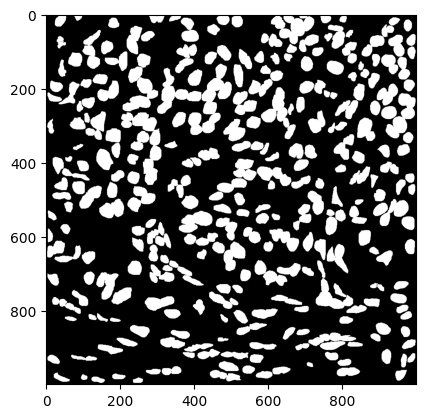